# Step 3: Compute a force directed layout

- implement a force directed layout;
- explain your choice of forces/parameters
- draw the result (Les Misérables network and Jazz network)
- comment on the quality of the resulting drawing; which (other) quality metrics could be optimized to improve your results?


- make it scalable for hyper parameter tuning for every graph; <- with grid search

## setup

libraries:

In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path

graphs' datasets:

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot" #tree
data_name_2 = "../Dataset/Step1/LesMiserables.dot" #tree
data_name_3 = "../Dataset/OTHERS/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/OTHERS/g.20.27.dot"
data_name_5 = "../Dataset/OTHERS/g.42.88.dot"
data_name_6 = "../Dataset/OTHERS/GD97.dot"
data_name_7 = "../Dataset/OTHERS/LeagueNetwork.dot" #tree
data_name_8 = "../Dataset/OTHERS/mesh graph.dot"
data_name_9 = "../Dataset/OTHERS/noname.dot"
data_name_10 = "../Dataset/OTHERS/polblogs.dot"
data_name_11 = "../Dataset/OTHERS/robot graph.dot"
data_name_12 = "../Dataset/OTHERS/rome.dot" #tree
data_name_13 = "../Dataset/OTHERS/snail graph.dot"

functions:

In [25]:
def draw_force_directed_graph_fruchterman_reingold(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    
    # Clean graph name for use as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    
    #
    n = len(nodes)
    print(f"Number of nodes: {n}")
    
    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    print(f"Canvas dimensions: {width} x {height}, area: {area}")
    
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size inversely proportional to sqrt(n)
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))  # SCALING: Edge width inversely proportional to sqrt(n)
    print(f"Node size: {node_size}, Font size: {font_size}, Edge width: {edge_width}")
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    print(f"Calculated l value: {l}")
    
    # SCALING: Initial temperature scales with canvas size
    t = width / 10
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    # SCALING: Adjust convergence threshold based on canvas size
    scaled_convergence = convergence_threshold * scale_factor
    
    # For each iteration
    i = 0
    while i < iterations and max_movement > scaled_convergence:
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both endpoints of the edge
            f_attr[u] += direction * attractive_magnitude
            f_attr[v] -= direction * attractive_magnitude
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        # Proportional cooling
        t = t * 0.95
        
        # Draw the graph every 10 iterations or at the last iteration or if converges
        if i % 10 == 0 or i == iterations - 1 or max_movement <= scaled_convergence:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', 
                         fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.1 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
    
    # Show convergence message
    if max_movement <= scaled_convergence:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    return pos  # Return final node positions

def c_auto_draw_force_directed_graph_fruchterman_reingold(file_path, iterations=100, C=None, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    
    # Clean graph name for use as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    
    # Graph statistics
    n = len(nodes)
    e = len(edges)
    print(f"Number of nodes: {n}")
    print(f"Number of edges: {e}")
    
    # Calculate graph density (ratio of actual edges to possible edges)
    max_possible_edges = n * (n - 1) / 2  # For undirected graphs
    density = e / max_possible_edges if max_possible_edges > 0 else 0
    print(f"Graph density: {density:.4f}")
    
    # AUTO-SCALING: Calculate optimal C based on graph characteristics if not provided
    if C is None:
        # Base C value determined by density
        # Dense graphs (density close to 1) -> C closer to 0.5
        # Sparse graphs (density close to 0) -> C closer to 2.0-3.0
        base_c = 2.5 - 2.0 * density
        
        # Adjust for node count (more nodes -> slightly higher C)
        node_factor = min(1.5, 1.0 + math.log(n) / 100)
        
        # Adjust for very high connectivity
        if density > 0.5:
            connectivity_factor = 0.7  # Reduce C for very dense graphs
        elif density < 0.05:
            connectivity_factor = 1.3  # Increase C for very sparse graphs
        else:
            connectivity_factor = 1.0  # Neutral for medium density
            
        # Calculate final C value
        C = base_c * node_factor * connectivity_factor
        
        # Ensure C is within reasonable bounds
        C = max(0.3, min(4.0, C))
        
        print(f"Auto-calculated C value: {C:.2f}")
    
    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    print(f"Canvas dimensions: {width} x {height}, area: {area}")
    
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size inversely proportional to sqrt(n)
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    print(f"Node size: {node_size}, Font size: {font_size}, Edge width: {edge_width}")
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    print(f"Calculated l value: {l}")
    
    # SCALING: Initial temperature scales with canvas size
    t = width / 10
    
    # IMPROVEMENT: Initialize node positions in a circle instead of random
    # This helps prevent early corner clustering
    pos = {}
    radius = min(width, height) / 2.5
    center_x, center_y = width/2, height/2
    for i, node in enumerate(nodes):
        angle = 2 * math.pi * i / n
        pos[node] = np.array([
            center_x + radius * math.cos(angle),
            center_y + radius * math.sin(angle)
        ])
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    # SCALING: Adjust convergence threshold based on canvas size
    scaled_convergence = convergence_threshold * scale_factor
    
    # For each iteration
    i = 0
    while i < iterations and max_movement > scaled_convergence:
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both endpoints of the edge
            f_attr[u] += direction * attractive_magnitude
            f_attr[v] -= direction * attractive_magnitude
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # IMPROVEMENT: Add weak gravity toward center to prevent corner clustering
            center = np.array([width/2, height/2])
            gravity_vector = center - pos[v]
            gravity_dist = max(0.1, np.linalg.norm(gravity_vector))
            gravity_dir = gravity_vector / gravity_dist
            gravity_strength = 0.01 * l  # Scale gravity with l
            f_total[v] += gravity_dir * gravity_strength
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        # Proportional cooling
        t = t * 0.95
        
        # Draw the graph every 10 iterations or at the last iteration or if converges
        if i % 10 == 0 or i == iterations - 1 or max_movement <= scaled_convergence:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', 
                         fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.1 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C:.2f}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C:.2f}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
    
    # Show convergence message
    if max_movement <= scaled_convergence:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    return pos  # Return final node positions

## usage:

In [18]:
def c_auto_draw_force_directed_graph_fruchterman_reingold(file_path, iterations=100, C=None, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    
    # Clean graph name for use as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    
    # Graph statistics
    n = len(nodes)
    e = len(edges)
    print(f"Number of nodes: {n}")
    print(f"Number of edges: {e}")
    
    # Calculate graph density (ratio of actual edges to possible edges)
    max_possible_edges = n * (n - 1) / 2  # For undirected graphs
    density = e / max_possible_edges if max_possible_edges > 0 else 0
    print(f"Graph density: {density:.4f}")
    
    # AUTO-SCALING: Calculate optimal C based on graph characteristics if not provided
    if C is None:
        # Base C value determined by density
        # Dense graphs (density close to 1) -> C closer to 0.5
        # Sparse graphs (density close to 0) -> C closer to 2.0-3.0
        base_c = 2.5 - 2.0 * density
        
        # Adjust for node count (more nodes -> slightly higher C)
        node_factor = min(1.5, 1.0 + math.log(n) / 100)
        
        # Adjust for very high connectivity
        if density > 0.5:
            connectivity_factor = 0.7  # Reduce C for very dense graphs
        elif density < 0.05:
            connectivity_factor = 1.3  # Increase C for very sparse graphs
        else:
            connectivity_factor = 1.0  # Neutral for medium density
            
        # Calculate final C value
        C = base_c * node_factor * connectivity_factor
        
        # Ensure C is within reasonable bounds
        C = max(0.3, min(4.0, C))
        
        print(f"Auto-calculated C value: {C:.2f}")
    
    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    print(f"Canvas dimensions: {width} x {height}, area: {area}")
    
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size inversely proportional to sqrt(n)
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    print(f"Node size: {node_size}, Font size: {font_size}, Edge width: {edge_width}")
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    print(f"Calculated l value: {l}")
    
    # SCALING: Initial temperature scales with canvas size
    t = width / 10
    
    # IMPROVEMENT: Initialize node positions in a circle instead of random
    # This helps prevent early corner clustering
    pos = {}
    radius = min(width, height) / 2.5
    center_x, center_y = width/2, height/2
    for i, node in enumerate(nodes):
        angle = 2 * math.pi * i / n
        pos[node] = np.array([
            center_x + radius * math.cos(angle),
            center_y + radius * math.sin(angle)
        ])
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    # SCALING: Adjust convergence threshold based on canvas size
    scaled_convergence = convergence_threshold * scale_factor
    
    # For each iteration
    i = 0
    while i < iterations and max_movement > scaled_convergence:
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both endpoints of the edge
            f_attr[u] += direction * attractive_magnitude
            f_attr[v] -= direction * attractive_magnitude
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # IMPROVEMENT: Add weak gravity toward center to prevent corner clustering
            center = np.array([width/2, height/2])
            gravity_vector = center - pos[v]
            gravity_dist = max(0.1, np.linalg.norm(gravity_vector))
            gravity_dir = gravity_vector / gravity_dist
            gravity_strength = 0.01 * l  # Scale gravity with l
            f_total[v] += gravity_dir * gravity_strength
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        # Proportional cooling
        t = t * 0.95
        
        # Draw the graph every 10 iterations or at the last iteration or if converges
        if i % 10 == 0 or i == iterations - 1 or max_movement <= scaled_convergence:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', 
                         fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.1 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C:.2f}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C:.2f}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
    
    # Show convergence message
    if max_movement <= scaled_convergence:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    return pos  # Return final node positions

Number of nodes: 100
Canvas dimensions: 2.5 x 2.5, area: 6.25
Node size: 80.0, Font size: 4, Edge width: 0.5
Calculated l value: 0.5
Saved frame 1 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0001.png


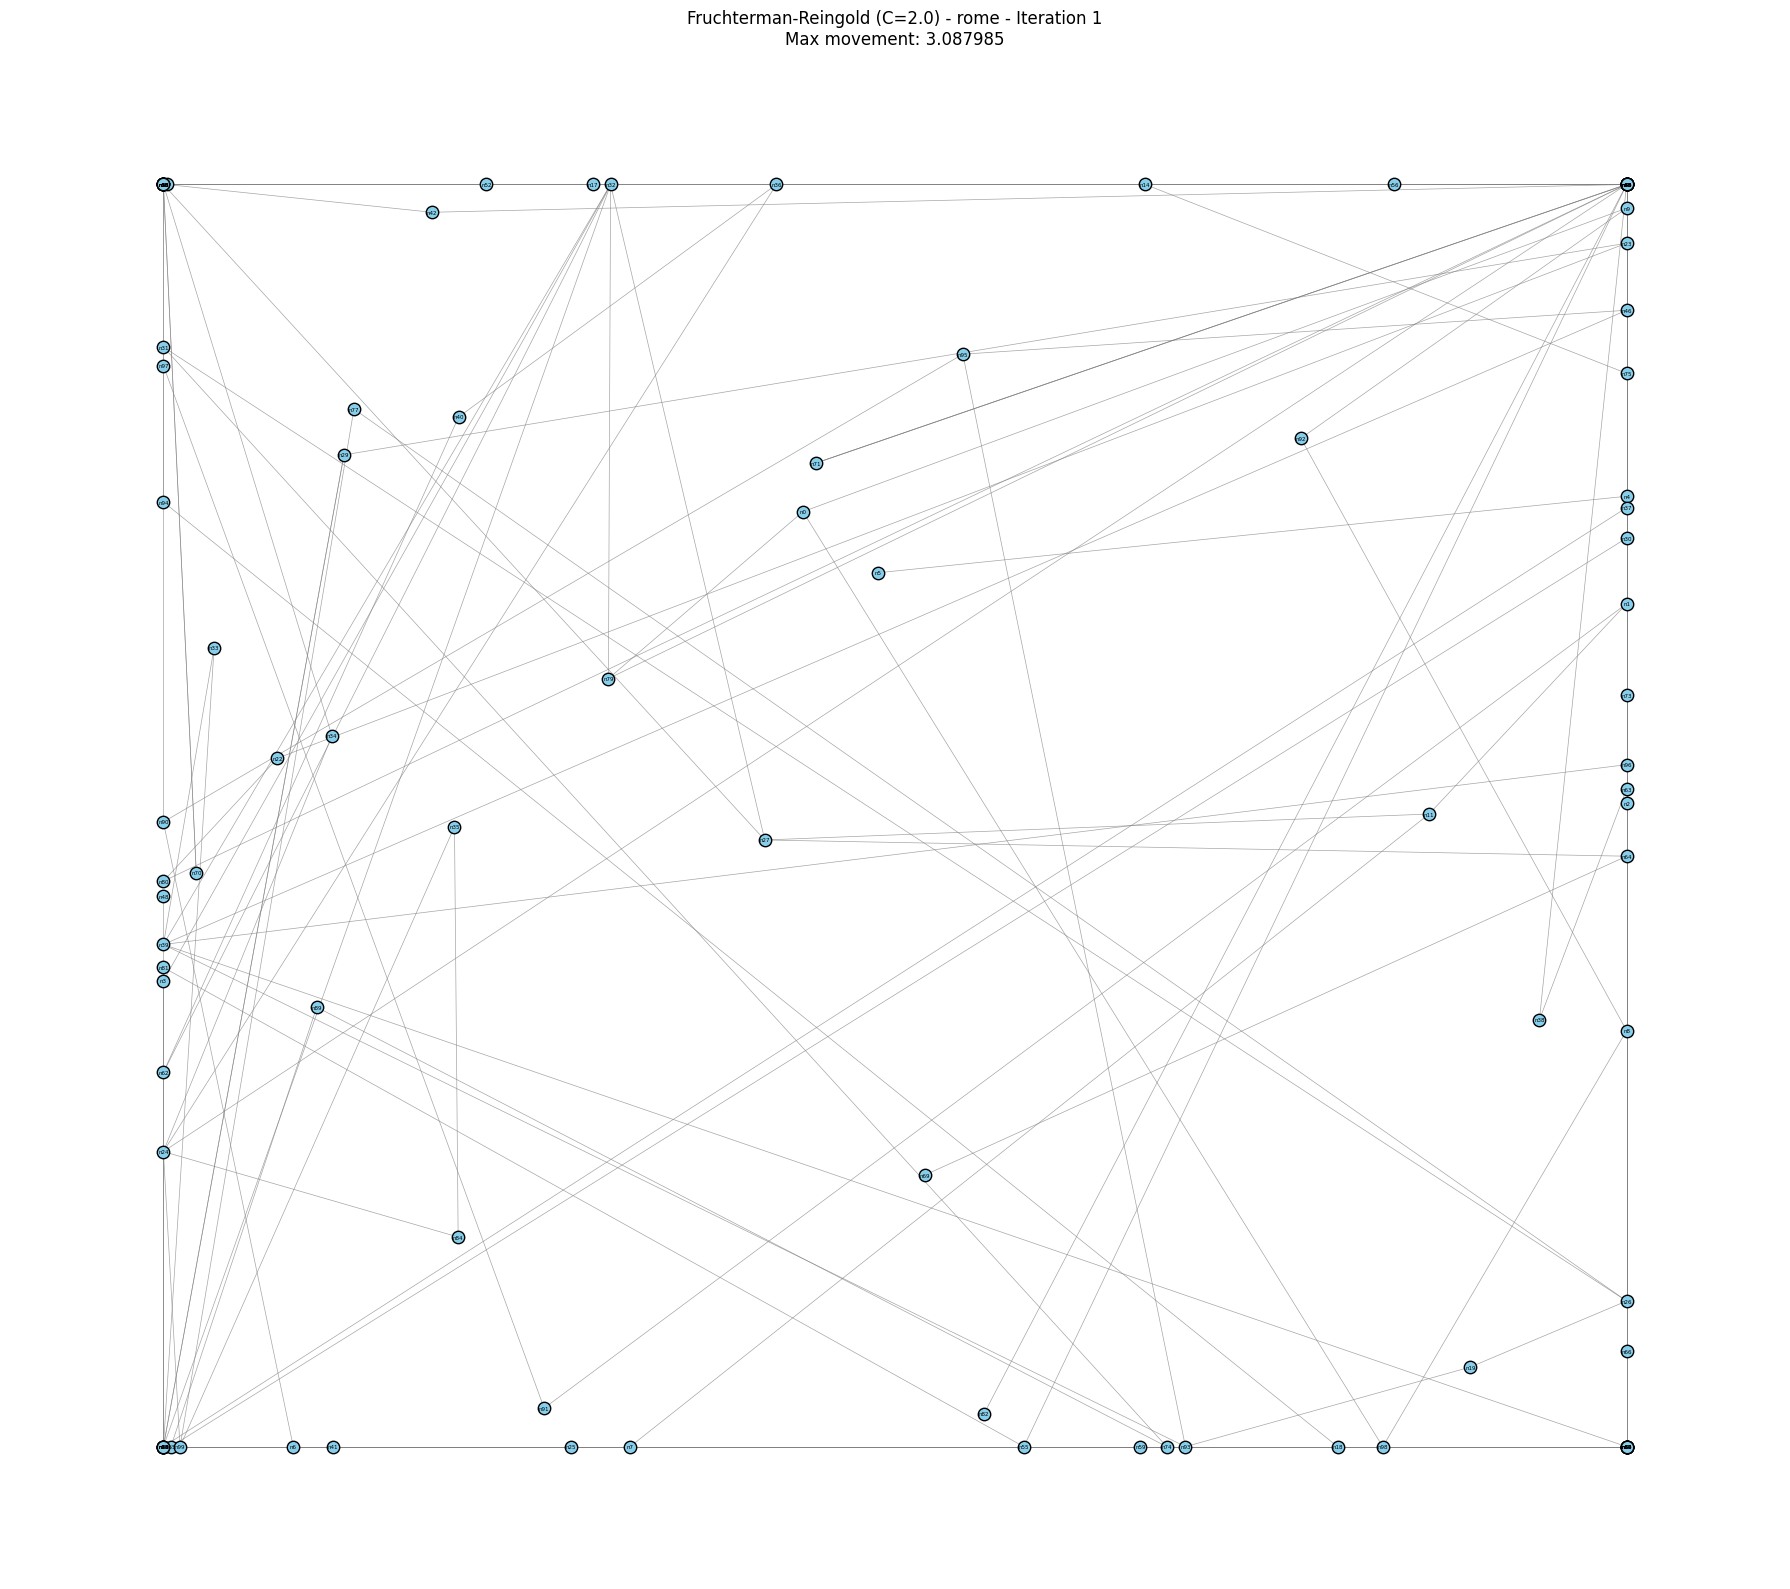

Saved frame 11 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0011.png


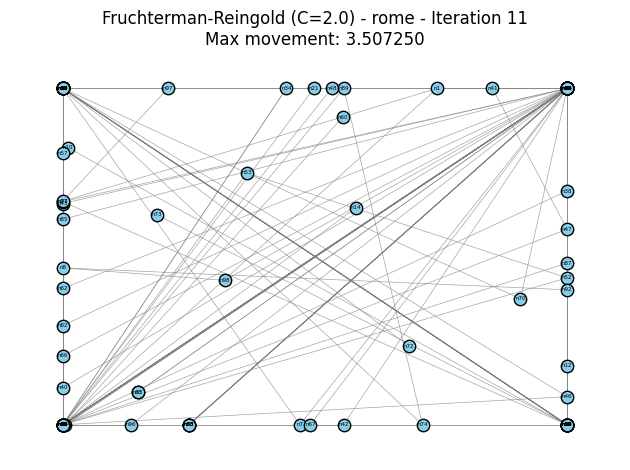

Saved frame 21 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0021.png


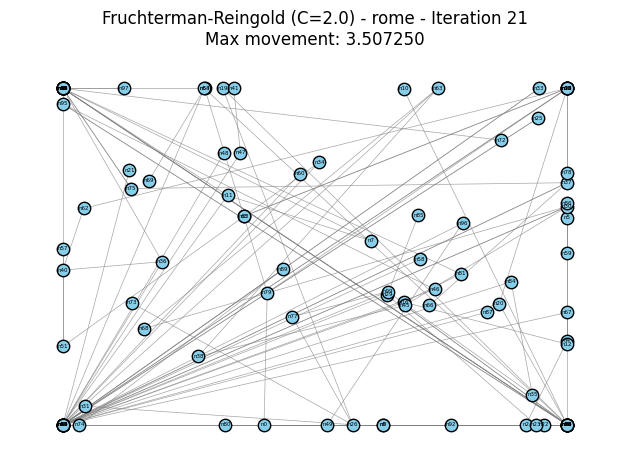

Saved frame 31 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0031.png


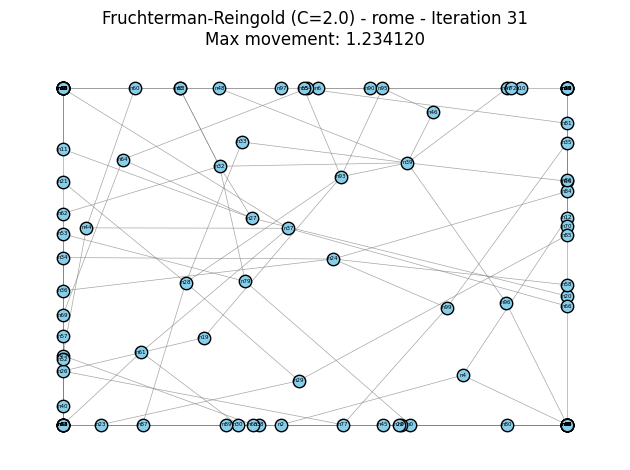

Saved frame 41 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0041.png


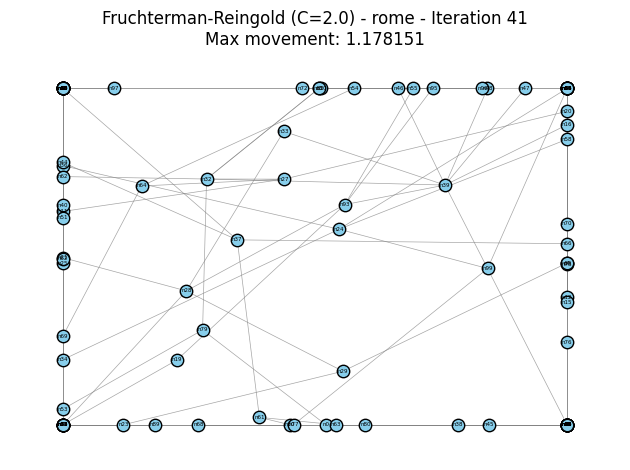

Saved frame 51 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0051.png


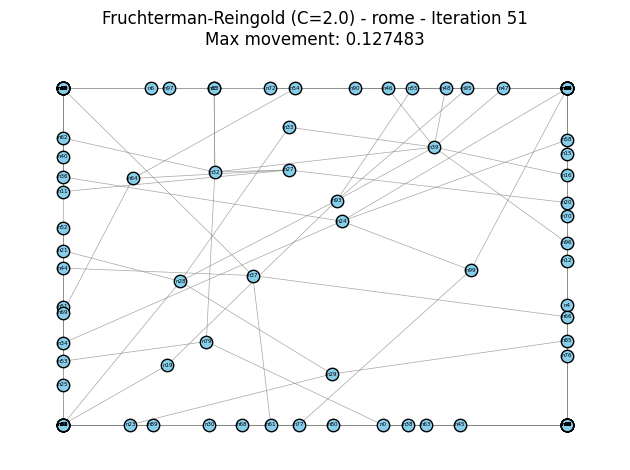

Saved frame 61 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0061.png


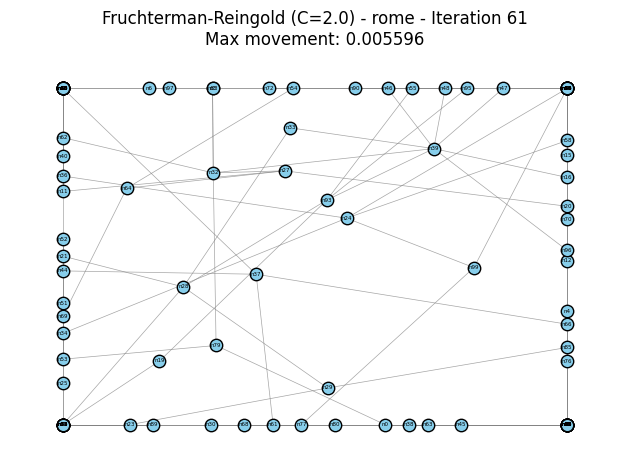

Saved frame 71 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0071.png


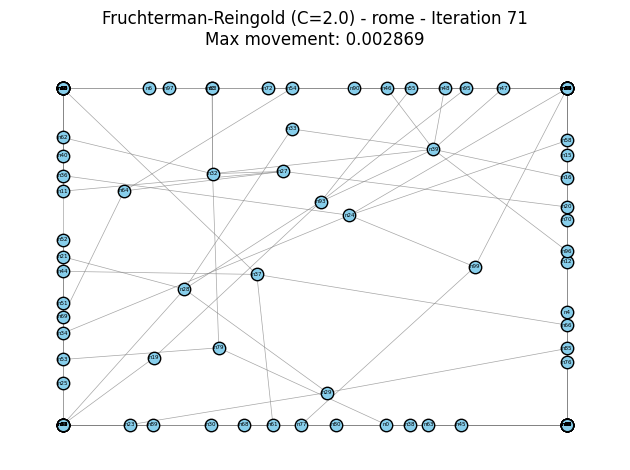

Saved frame 74 to ../Outputs_force/rome.dot/rome_FR_C2.0_iter_0074.png


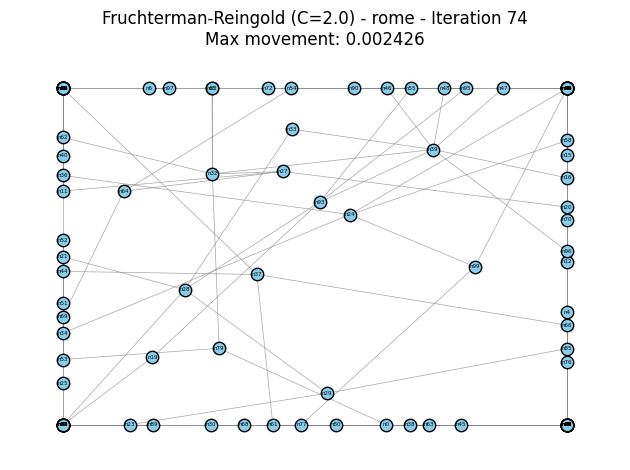

Algorithm converged at iteration 74 with maximum movement 0.002426


{'n0': array([1.60149764, 0.01      ]),
 'n1': array([0.01, 2.49]),
 'n2': array([2.49, 0.01]),
 'n3': array([0.74418568, 2.49      ]),
 'n4': array([2.49      , 0.83976948]),
 'n5': array([2.49, 0.01]),
 'n6': array([0.43453766, 2.49      ]),
 'n7': array([0.01, 2.49]),
 'n8': array([2.49, 0.01]),
 'n9': array([2.49, 0.01]),
 'n10': array([2.49, 2.49]),
 'n11': array([0.01      , 1.73276783]),
 'n12': array([2.49      , 1.21144947]),
 'n13': array([0.01, 2.49]),
 'n14': array([0.01, 2.49]),
 'n15': array([2.49      , 1.99682296]),
 'n16': array([2.49     , 1.8299345]),
 'n17': array([0.01, 2.49]),
 'n18': array([2.49, 2.49]),
 'n19': array([0.45002356, 0.50688727]),
 'n20': array([2.49     , 1.6150473]),
 'n21': array([0.01      , 1.24844203]),
 'n22': array([0.01, 0.01]),
 'n23': array([0.33845213, 0.01      ]),
 'n24': array([1.42163329, 1.55952786]),
 'n25': array([0.01      , 0.31434605]),
 'n26': array([0.01, 0.01]),
 'n27': array([1.09194474, 1.87737851]),
 'n28': array([0.60904

In [ ]:
# Path to your .dot file
dot_file_path = data_name_12

# Draw the graph with the Fruchterman-Reingold algorithm with auto-calculated C
c_auto_draw_force_directed_graph_fruchterman_reingold(
    dot_file_path, 
    iterations=200,
    C=None,  # None means auto-calculate C based on graph properties
    convergence_threshold=0.001
)

In [ ]:
# Or override with a specific C

# Path to your .dot file
dot_file_path = data_name_12

draw_force_directed_graph_fruchterman_reingold(
    dot_file_path, 
    iterations=200,
    C=2.0,  
    convergence_threshold=0.001
)